In [1]:
import os
import argparse

import matplotlib.pyplot as plt
import numpy as np

from datatree import open_datatree
from scipy.stats import describe

from var_assim.plotting.presets import get_presets
from var_assim.plotting.bias_perc_error_over_time import make_cleaned_datatree_list
from var_assim.plotting.filtering import filter_by_max_conceivable
from var_assim.plotting.pproc import get_angle_r2, get_angles_for_dt_list, get_angle_r3
from var_assim.config import PRIOR_PATH, NOISE_PATH, TRUTH_PATH, WINDOW_PATH, FIGS_DIR
from var_assim.calibration.priors import ClimateModelPriors
from var_assim.calibration.noise import ClimateModelNoise
from var_assim.calibration.truth import ClimateModelTruth
from var_assim.calibration.windowing import AssimilationWindowing

In [2]:
presets, basefile = get_presets()
plt.rcParams.update(presets)
SAVE_FIGS = True

In [3]:
def gen_filenames(cwd, prefix, ssp, model, TMIN, 
                  AR, reg_noise, noise_model, thetas, ECS, 
                  DEGpDEC, NYRSRAMP, windowing_config, Nens, sai_ramp=None):

    if reg_noise:
        AR = str(AR) + '+reg'
    if sai_ramp is None:
        # import files and convert to datatrees
        if (model == 'pco2geowc_nn' or model == 'pco2geowc3_nn'):
            fnames = [
                cwd + '/../../data/output/' + model + '/'
                + prefix + '_' + ssp + '_' + model + '_' + windowing_config + '_' + noise_model
                + '_TMIN' + str(TMIN) + '_THETA' + th + '_ECS' + str(ECS)
                + '_DEGpDEC' + DEGpDEC + '_NYRSRAMP' + str(NYRSRAMP) + '_Nens' + str(Nens) + '.nc'
                for th in thetas
            ]

        else:    
            fnames = [
                cwd + '/../../data/output/' + model + '/'
                + prefix + '_' + ssp + '_' + model + '_' + windowing_config + '_AR' + AR
                + '_TMIN' + str(TMIN) + '_THETA' + th + '_ECS' + str(ECS)
                + '_DEGpDEC' + DEGpDEC + '_NYRSRAMP' + str(NYRSRAMP) + '_Nens' + str(Nens) + '.nc'
                for th in thetas
            ]

    else:
        # import files and convert to datatrees
        if (model == 'pco2geowc_nn' or model == 'pco2geowc3_nn'):
            fnames = [
                cwd + '/../../data/output/' + model + '/'
                + prefix + '_' + ssp + '_' + model + '_' + windowing_config + '_' + noise_model
                + '_TMIN' + str(TMIN) + '_THETA' + th + '_ECS' + str(ECS)
                + '_ramprate' + sai_ramp + '_DEGpDEC' + DEGpDEC + '_NYRSRAMP' + str(NYRSRAMP) + '_Nens' + str(Nens) + '.nc'
                for th in thetas
            ]

        else:    
            fnames = [
                cwd + '/../../data/output/' + model + '/'
                + prefix + '_' + ssp + '_' + model + '_' + windowing_config + '_AR' + AR
                + '_TMIN' + str(TMIN) + '_THETA' + th + '_ECS' + str(ECS)
                + '_ramprate' + sai_ramp + '_DEGpDEC' + DEGpDEC + '_NYRSRAMP' + str(NYRSRAMP) + '_Nens' + str(Nens) + '.nc'
                for th in thetas
            ]

    return fnames

In [6]:
# simulation config
cwd = os.getcwd()
prefix = 'var-assim-output'
ssp = 'ssp245'
model = 'pco2geowc_reg_noic'
reg_noise = True
TMIN = 2025
AR = '1'
noise_model = 'AR1'
angles_file = ['5', '11', '15', '21', '30', '35']
ECS = 3.0
DEGpDEC = '0.1'
NYRSRAMP = 50
windowing_config = 'four'
Nens = 1000

fnames = gen_filenames(cwd, prefix, ssp, model, TMIN, AR, reg_noise, noise_model,
                       angles_file, ECS, DEGpDEC, NYRSRAMP, windowing_config,
                       Nens, sai_ramp='linear')

fnames

['/project/bbcael/ambauer/learning_sai/analysis/notebooks/../../data/output/pco2geowc_reg_noic/var-assim-output_ssp245_pco2geowc_reg_noic_four_AR1+reg_TMIN2025_THETA5_ECS3.0_rampratelinear_DEGpDEC0.1_NYRSRAMP50_Nens1000.nc',
 '/project/bbcael/ambauer/learning_sai/analysis/notebooks/../../data/output/pco2geowc_reg_noic/var-assim-output_ssp245_pco2geowc_reg_noic_four_AR1+reg_TMIN2025_THETA11_ECS3.0_rampratelinear_DEGpDEC0.1_NYRSRAMP50_Nens1000.nc',
 '/project/bbcael/ambauer/learning_sai/analysis/notebooks/../../data/output/pco2geowc_reg_noic/var-assim-output_ssp245_pco2geowc_reg_noic_four_AR1+reg_TMIN2025_THETA15_ECS3.0_rampratelinear_DEGpDEC0.1_NYRSRAMP50_Nens1000.nc',
 '/project/bbcael/ambauer/learning_sai/analysis/notebooks/../../data/output/pco2geowc_reg_noic/var-assim-output_ssp245_pco2geowc_reg_noic_four_AR1+reg_TMIN2025_THETA21_ECS3.0_rampratelinear_DEGpDEC0.1_NYRSRAMP50_Nens1000.nc',
 '/project/bbcael/ambauer/learning_sai/analysis/notebooks/../../data/output/pco2geowc_reg_noic/va

In [7]:
cli_args = argparse.Namespace(
    model=model,
    ssp=ssp,
    noise_model=f"AR{AR}" if (model != 'pco2geowc_nn' and model != 'pco2geowc3_nn') else 'nn',
    tmin=TMIN,
    AR=1,
    ECS=ECS,
    DEGpDEC=DEGpDEC,
    NYRSRAMP=NYRSRAMP,
    Nens=Nens,
    reg_noise=reg_noise,
    windowing=windowing_config
)

Noise = ClimateModelNoise.from_cli_and_yaml(cli_args, NOISE_PATH)
Prior = ClimateModelPriors.from_cli_and_yaml_and_noise(cli_args, PRIOR_PATH, Noise)
Windowing = AssimilationWindowing.from_cli_and_yaml(cli_args, WINDOW_PATH)

In [8]:
dt_meta = open_datatree(fnames[0], engine='netcdf4')

In [9]:
relevant_vars = ['cost_hist', 'controls', 'controls_hist']
all_vars = [x for x in dt_meta['2040'].ds.data_vars]
dropped_vars = [v for v in all_vars if v not in relevant_vars]
dropped_vars


['data_final',
 'l2s',
 'costs',
 'data_hist',
 'l2_hist',
 'flag',
 'obs',
 'data_truth',
 'controls_truth']

In [10]:
dts_clean = make_cleaned_datatree_list(fnames, angles_file, dropped_vars, THRESHOLD=5e-1)

Processing angle = 5...
Found 5 nodes in tree
Processing node 1: /2040
  Memory: 24.0 MB
  Result: 997 kept, 3 filtered
Processing node 2: /2060
  Memory: 47.5 MB
  Result: 997 kept, 3 filtered
Processing node 3: /2080
  Memory: 71.1 MB
  Result: 998 kept, 2 filtered
Processing node 4: /2100
  Memory: 94.7 MB
  Result: 998 kept, 2 filtered

Rebuilding tree with 4 filtered nodes...
✓ Filtering complete
Processing angle = 11...
Found 5 nodes in tree
Processing node 1: /2040
  Memory: 24.0 MB
  Result: 997 kept, 3 filtered
Processing node 2: /2060
  Memory: 47.5 MB
  Result: 997 kept, 3 filtered
Processing node 3: /2080
  Memory: 71.1 MB
  Result: 998 kept, 2 filtered
Processing node 4: /2100
  Memory: 94.7 MB
  Result: 998 kept, 2 filtered

Rebuilding tree with 4 filtered nodes...
✓ Filtering complete
Processing angle = 15...
Found 5 nodes in tree
Processing node 1: /2040
  Memory: 24.0 MB
  Result: 997 kept, 3 filtered
Processing node 2: /2060
  Memory: 47.5 MB
  Result: 998 kept, 2 fil

In [11]:
# important simulation constants
L_CEN = Prior.L_CEN
G_CEN = Prior.G_CEN
EPS_CEN = Prior.EPS_CEN
F_EFF_GEO = 0.09  # hard constant
ALPHA_R1_CEN = Prior.ALPHA_CEN[0]
ALPHA_R2_CEN = Prior.ALPHA_CEN[1]

In [12]:
dat = dts_clean[0]

In [13]:
angles_tr = np.zeros(6)

for idx, angle in enumerate(angles_file):
    tmp_cli = argparse.Namespace(
        model=model,
        ssp=ssp,
        noise_model=f"AR{AR}" if (model != 'pco2geowc_nn' and model != 'pco2geowc3_nn') else 'nn',
        tmin=TMIN,
        AR=1,
        ecs=ECS,
        theta=float(angle),
        deg_p_dec=DEGpDEC,
        nyrsramp=NYRSRAMP,
        n_ens=Nens,
        reg_noise=reg_noise,
        windowing=windowing_config
    )
    tmp_truth = ClimateModelTruth.from_cli_and_yaml(tmp_cli, TRUTH_PATH)

    if '3' in model:
        angles_tr[idx] = get_angle_r3(
            tmp_truth.ALPHA_TR[0], tmp_truth.ALPHA_TR[1], tmp_truth.ALPHA_TR[2],
            tmp_truth.BETA_TR[0], tmp_truth.BETA_TR[1], tmp_truth.BETA_TR[2],
            tmp_truth.L_TR, tmp_truth.EPS_TR, tmp_truth.G_TR
        )
    else:
        angles_tr[idx] = get_angle_r2(
            tmp_truth.ALPHA_TR[0], tmp_truth.ALPHA_TR[1],
            tmp_truth.BETA_TR[0], tmp_truth.BETA_TR[1],
            tmp_truth.L_TR, tmp_truth.EPS_TR, tmp_truth.G_TR
        )

angles_tr

array([ 5., 11., 15., 21., 30., 35.])

In [14]:
# pull prior distributions
w1 = '2040'
prior_a1 = dat[w1].ds.controls_hist.sel(vari='ALPHA_R1', iter=0).values
prior_b1 = dat[w1].ds.controls_hist.sel(vari='BETA_R1', iter=0).values
prior_a2 = dat[w1].ds.controls_hist.sel(vari='ALPHA_R2', iter=0).values
prior_b2 = dat[w1].ds.controls_hist.sel(vari='BETA_R2', iter=0).values
prior_l = dat[w1].ds.controls_hist.sel(vari='L', iter=0).values
prior_g = dat[w1].ds.controls_hist.sel(vari='G', iter=0).values
prior_eps = dat[w1].ds.controls_hist.sel(vari='EPS', iter=0).values

# add third region stuff if necessary
prior_a3 = dat[w1].ds.controls_hist.sel(vari='ALPHA_R3', iter=0).values if '3' in model else None
prior_b3 = dat[w1].ds.controls_hist.sel(vari='BETA_R3', iter=0).values if '3' in model else None

# compute priors
angles_prior = np.zeros(Nens)
for i in range(Nens):
    if '3' in model:
        angles_prior[i] = get_angle_r3(prior_a1[i], prior_a2[i], prior_a3[i], prior_b1[i], prior_b2[i], prior_b3[i], prior_l[i], prior_eps[i], prior_g[i])
    else:
        angles_prior[i] = get_angle_r2(prior_a1[i], prior_a2[i], prior_b1[i], prior_b2[i], prior_l[i], prior_eps[i], prior_g[i])

# describe for the people
describe(angles_prior, nan_policy='omit')

DescribeResult(nobs=997, minmax=(masked_array(data=0.06347208,
             mask=False,
       fill_value=1e+20), masked_array(data=98.09213781,
             mask=False,
       fill_value=1e+20)), mean=15.911632225881359, variance=66.58083065406538, skewness=masked_array(data=1.51727384,
             mask=False,
       fill_value=1e+20), kurtosis=10.274969623875966)

In [15]:
np.nanmedian(angles_prior)

15.188732931544298

In [16]:
winds = np.array([w[1] for w in Windowing.windows])
windss = [str(w) for w in winds]

In [17]:
N_reg = 3 if '3' in model else 2
angles = get_angles_for_dt_list(dts_clean, windss, Nens, N_reg)

In [18]:
ANGLE_MAX_CONCEIVABLE = 90.
angles_filtered = filter_by_max_conceivable(angles, ANGLE_MAX_CONCEIVABLE)
angles_filtered.shape

(6, 4, 1000)

Figure saved to /project/bbcael/ambauer/learning_sai/analysis/figs/results/ens-med-bias-percrange-pco2geowc_reg_noic-ssp245-TMIN2025-AR1-ECS3.0-DEGpDEC0.1-four-Nens1000.png


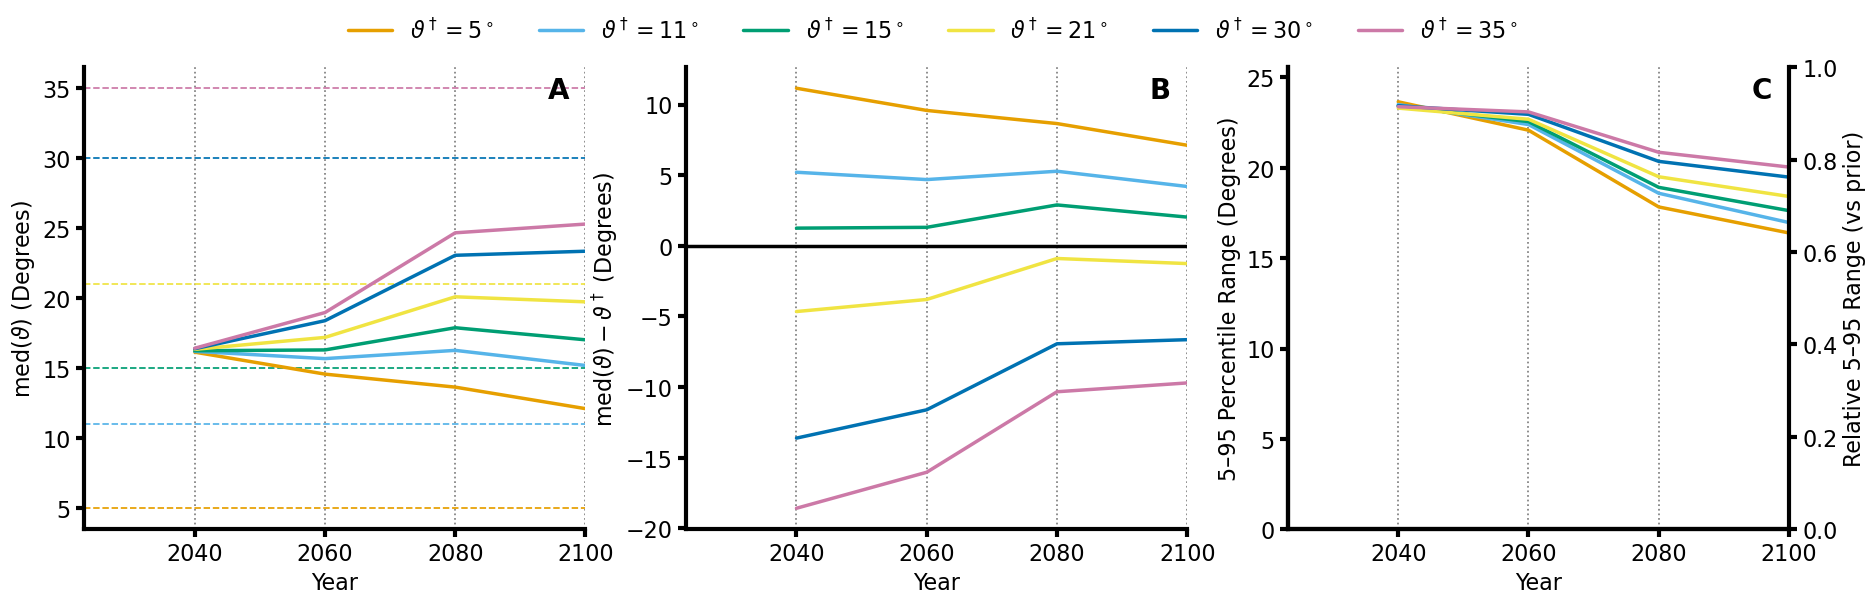

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(22, 6))
color_list = ['#000000', '#E69F00', '#56B4E9', '#009E73', '#F0E442',
              '#0072B2', '#CC79A7', '#D55E00']

YMIN, YMAX = 5, 25
PLO, PHI = 5, 95

PRIOR_RANGE = np.nanpercentile(angles_prior, PHI) - np.nanpercentile(angles_prior, PLO)
YUB = PRIOR_RANGE

for a in ax:
    a.set_xlim((2023, 2100))

for w in winds:
    for a in ax:
        a.axvline(w, linestyle='dotted', color='grey', linewidth=1.25)
        a.set_xlabel("Year")

for i in range(len(angles_file)):
    ax[0].plot(winds, np.nanmedian(angles_filtered[i], axis=1),
               linestyle='solid', color=color_list[i+1],
               label=r'$\vartheta^\dagger=${}$^\circ$'.format(angles_file[i]), zorder=100)

    ax[0].axhline(angles_tr[i], linestyle='dashed', linewidth=1.25, color=color_list[i+1])

    ax[1].plot(winds, np.nanmedian(angles_filtered[i], axis=1) - angles_tr[i], 
           color=color_list[i+1], zorder=100, linestyle='solid')

    ax[2].plot(winds, np.nanpercentile(angles_filtered[i], PHI, axis=1) - np.nanpercentile(angles_filtered[i], PLO, axis=1), 
           label=r'$\vartheta*=${}$^\circ$'.format(angles_file[0]), zorder=100, color=color_list[i+1], linestyle='solid')

ax[0].set_ylabel(r"med$(\vartheta)$ (Degrees)")
ax[0].legend(bbox_to_anchor=(2.9, 1.15), ncols=len(angles_file))

ax[1].set_ylabel(r"med$(\vartheta) - \vartheta^\dagger$ (Degrees)")
ax[1].axhline(0, color='k', linestyle='solid')

ax[2].set_ylabel(f"{PLO}–{PHI} Percentile Range (Degrees)")
ax[2].set_ylim((0, YUB))

ax2_rel = ax[2].twinx()
ax2_rel.set_ylabel(f"Relative {PLO}–{PHI} Range (vs prior)")
ax2_rel.spines['right'].set_visible(True)
ax2_rel.set_ylim((0, YUB / PRIOR_RANGE))

# Add bold, all-caps panel labels
for a, label in zip(ax, ['A', 'B', 'C']):
    a.text(0.925, 0.98, label, transform=a.transAxes,
           fontsize=20, fontweight='bold', va='top', ha='left')

if SAVE_FIGS:
    filename = f"ens-med-bias-percrange-{model}-{ssp}-TMIN{TMIN}-AR{AR}-ECS{ECS}-DEGpDEC{DEGpDEC}-{windowing_config}-Nens{Nens}.png"
    fig.savefig(FIGS_DIR / 'results' / (basefile+filename), dpi=350, bbox_inches='tight')
    print("Figure saved to {}".format(FIGS_DIR / 'results' / filename))

plt.show()

In [20]:
FIGS_DIR

PosixPath('/project/bbcael/ambauer/learning_sai/analysis/figs')

Figure saved to 2026-9-24-filled-ens-med-bias-percrange-pco2geowc_reg_noic-ssp245-TMIN2025-AR1-ECS3.0-DEGpDEC0.1-four-Nens1000.png


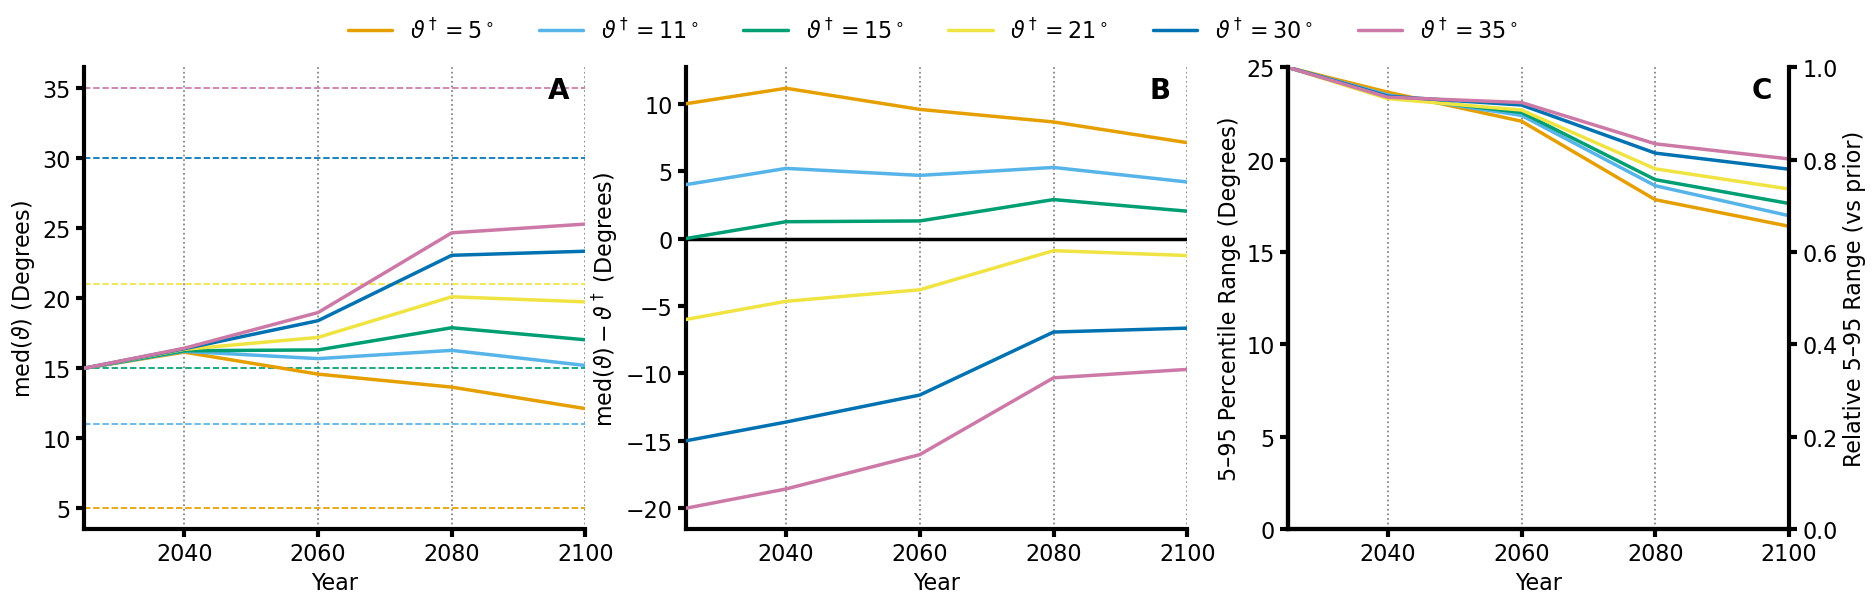

In [22]:
# plot with priors pinned at first assimilation window
medians_filled = np.zeros((len(angles_file), len(winds) + 1))
medians_filled[:, 0] = 15
medians_filled[:, 1:] = np.nanmedian(angles_filtered, axis=2)

bias_filled = np.zeros((len(angles_file), len(winds) + 1))
bias_filled[:, 0] = 15 - angles_tr
bias_filled[:, 1:] = np.nanmedian(angles_filtered, axis=2) - angles_tr[:, None]

perc_filled = np.zeros((len(angles_file), len(winds) + 1))
perc_filled[:, 0] = 25
perc_filled[:, 1:] = np.nanpercentile(angles_filtered, PHI, axis=2) - np.nanpercentile(angles_filtered, PLO, axis=2)

fig, ax = plt.subplots(1, 3, figsize=(22, 6))
color_list = ['#000000', '#E69F00', '#56B4E9', '#009E73', '#F0E442',
              '#0072B2', '#CC79A7', '#D55E00']

YMIN, YMAX = 5, 25
PLO, PHI = 5, 95

PRIOR_RANGE = np.nanpercentile(angles_prior, PHI) - np.nanpercentile(angles_prior, PLO)
YUB = PRIOR_RANGE

for a in ax:
    a.set_xlim((TMIN, 2100))

for w in winds:
    for a in ax:
        a.axvline(w, linestyle='dotted', color='grey', linewidth=1.25)
        a.set_xlabel("Year")

for i in range(len(angles_file)):
    ax[0].plot(np.hstack([[2025], winds]), medians_filled[i],
               linestyle='solid', color=color_list[i+1],
               label=r'$\vartheta^\dagger=${}$^\circ$'.format(angles_file[i]), zorder=100)

    ax[0].axhline(angles_tr[i], linestyle='dashed', linewidth=1.25, color=color_list[i+1])

    ax[1].plot(np.hstack([[2025], winds]), bias_filled[i], 
           color=color_list[i+1], zorder=100, linestyle='solid')

    ax[2].plot(np.hstack([[2025], winds]), perc_filled[i], 
           label=r'$\vartheta*=${}$^\circ$'.format(angles_file[0]), zorder=100, color=color_list[i+1], linestyle='solid')

ax[0].set_ylabel(r"med$(\vartheta)$ (Degrees)")
ax[0].legend(bbox_to_anchor=(2.9, 1.15), ncols=len(angles_file))

ax[1].set_ylabel(r"med$(\vartheta) - \vartheta^\dagger$ (Degrees)")
ax[1].axhline(0, color='k', linestyle='solid')

ax[2].set_ylabel(f"{PLO}–{PHI} Percentile Range (Degrees)")
ax[2].set_ylim((0, 25))

ax2_rel = ax[2].twinx()
ax2_rel.set_ylabel(f"Relative {PLO}–{PHI} Range (vs prior)")
ax2_rel.spines['right'].set_visible(True)
ax2_rel.set_ylim((0, YUB / PRIOR_RANGE))

# Add bold, all-caps panel labels
for a, label in zip(ax, ['A', 'B', 'C']):
    a.text(0.925, 0.98, label, transform=a.transAxes,
           fontsize=20, fontweight='bold', va='top', ha='left')

if SAVE_FIGS:
    filename = f"filled-ens-med-bias-percrange-{model}-{ssp}-TMIN{TMIN}-AR{AR}-ECS{ECS}-DEGpDEC{DEGpDEC}-{windowing_config}-Nens{Nens}.png"
    fig.savefig(FIGS_DIR / 'results' / (basefile+filename), dpi=350, bbox_inches='tight')
    print("Figure saved to {}".format(basefile + filename))

plt.show()

Figure saved to /project/bbcael/ambauer/learning_sai/analysis/notebooks/figs/2026-8-5-filled-ens-med-bias-percrange-pco2geowc3_reg-ssp245-TMIN2025-AR1-ECS3.0-DEGpDEC0.1-four-Nens1000.png


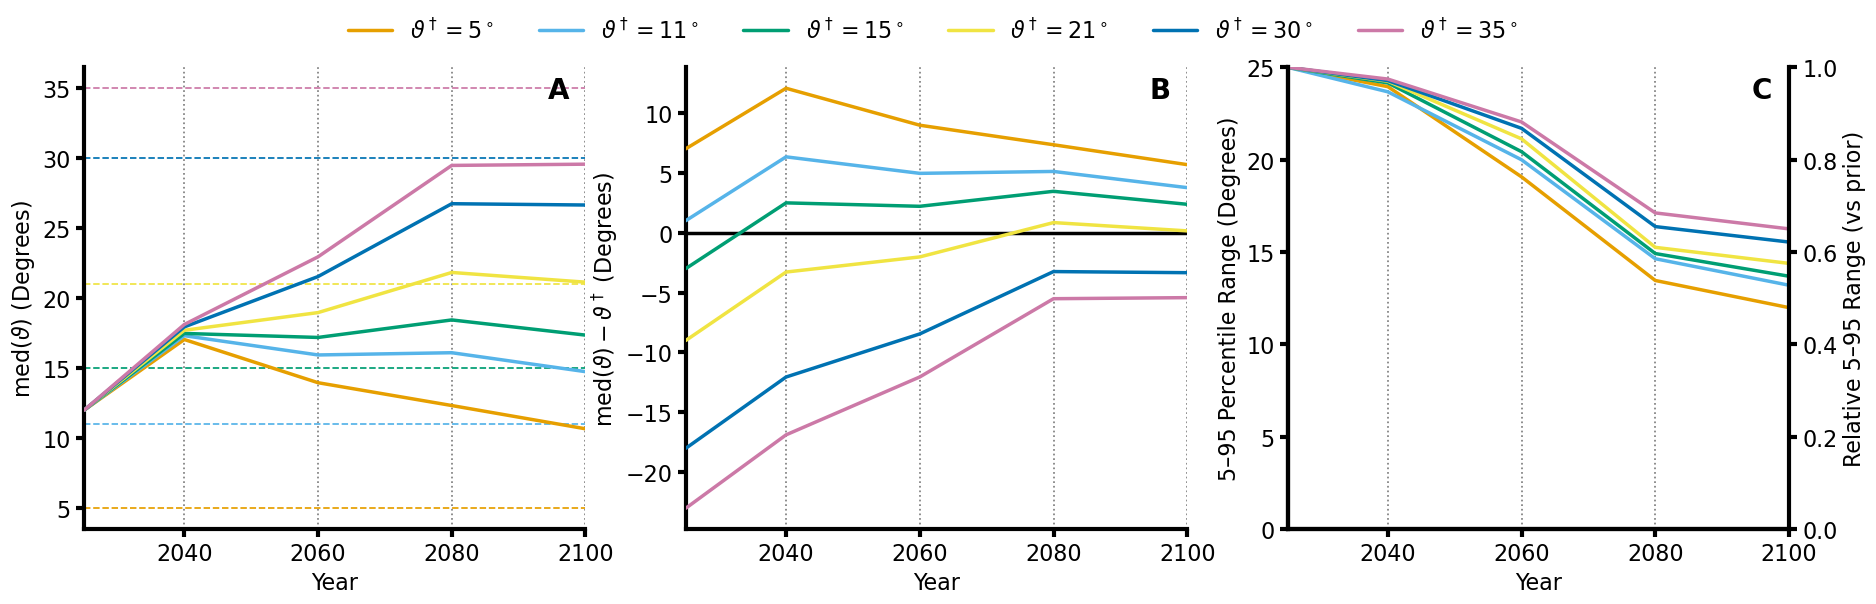

In [72]:
# plot with priors pinned at first assimilation window
medians_filled = np.zeros((len(angles_file), len(winds) + 1))
medians_filled[:, 0] = 12
medians_filled[:, 1:] = np.nanmean(angles_filtered, axis=2)

bias_filled = np.zeros((len(angles_file), len(winds) + 1))
bias_filled[:, 0] = 12 - angles_tr
bias_filled[:, 1:] = np.nanmean(angles_filtered, axis=2) - angles_tr[:, None]

perc_filled = np.zeros((len(angles_file), len(winds) + 1))
perc_filled[:, 0] = 25
perc_filled[:, 1:] = np.nanpercentile(angles_filtered, PHI, axis=2) - np.nanpercentile(angles_filtered, PLO, axis=2)

fig, ax = plt.subplots(1, 3, figsize=(22, 6))
color_list = ['#000000', '#E69F00', '#56B4E9', '#009E73', '#F0E442',
              '#0072B2', '#CC79A7', '#D55E00']

YMIN, YMAX = 5, 25
PLO, PHI = 5, 95

PRIOR_RANGE = np.nanpercentile(angles_prior, PHI) - np.nanpercentile(angles_prior, PLO)
YUB = PRIOR_RANGE

for a in ax:
    a.set_xlim((TMIN, 2100))

for w in winds:
    for a in ax:
        a.axvline(w, linestyle='dotted', color='grey', linewidth=1.25)
        a.set_xlabel("Year")

for i in range(len(angles_file)):
    ax[0].plot(np.hstack([[2025], winds]), medians_filled[i],
               linestyle='solid', color=color_list[i+1],
               label=r'$\vartheta^\dagger=${}$^\circ$'.format(angles_file[i]), zorder=100)

    ax[0].axhline(angles_tr[i], linestyle='dashed', linewidth=1.25, color=color_list[i+1])

    ax[1].plot(np.hstack([[2025], winds]), bias_filled[i], 
           color=color_list[i+1], zorder=100, linestyle='solid')

    ax[2].plot(np.hstack([[2025], winds]), perc_filled[i], 
           label=r'$\vartheta*=${}$^\circ$'.format(angles_file[0]), zorder=100, color=color_list[i+1], linestyle='solid')

ax[0].set_ylabel(r"med$(\vartheta)$ (Degrees)")
ax[0].legend(bbox_to_anchor=(2.9, 1.15), ncols=len(angles_file))

ax[1].set_ylabel(r"med$(\vartheta) - \vartheta^\dagger$ (Degrees)")
ax[1].axhline(0, color='k', linestyle='solid')

ax[2].set_ylabel(f"{PLO}–{PHI} Percentile Range (Degrees)")
ax[2].set_ylim((0, 25))

ax2_rel = ax[2].twinx()
ax2_rel.set_ylabel(f"Relative {PLO}–{PHI} Range (vs prior)")
ax2_rel.spines['right'].set_visible(True)
ax2_rel.set_ylim((0, YUB / PRIOR_RANGE))

# Add bold, all-caps panel labels
for a, label in zip(ax, ['A', 'B', 'C']):
    a.text(0.925, 0.98, label, transform=a.transAxes,
           fontsize=20, fontweight='bold', va='top', ha='left')

if SAVE_FIGS:
    filename = f"filled-ens-med-bias-percrange-{model}-{ssp}-TMIN{TMIN}-AR{AR}-ECS{ECS}-DEGpDEC{DEGpDEC}-{windowing_config}-Nens{Nens}.png"
    fig.savefig(FIGS_DIR / 'results' / filename, dpi=350, bbox_inches='tight')
    print("Figure saved to {}".format(basefile + filename))

plt.show()

In [56]:
dts_clean[0]['2100'].ds

<xarray.DatasetView>
Dimensions:          (ens_mem: 1000, vari: 15, iter: 101, time: 76, obs_var: 4)
Coordinates:
  * time             (time) int64 2025 2026 2027 2028 ... 2097 2098 2099 2100
  * iter             (iter) int64 0 1 2 3 4 5 6 7 8 ... 93 94 95 96 97 98 99 100
  * vari             (vari) object 'T1' 'T2' 'Q' ... 'BETA_R1' 'BETA_R2'
  * ens_mem          (ens_mem) int64 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
  * obs_var          (obs_var) object 'T1' 'Q' 'T_R1' 'T_R2'
Data variables:
    controls         (ens_mem, vari) float64 1.01 0.2949 ... -0.01357 0.001244
    cost_hist        (ens_mem, iter) float64 259.2 1.288 ... 0.01573 0.01573
    controls_hist    (ens_mem, vari, iter) float64 1.008 1.015 ... 0.001244
    cost_ratio_mask  (ens_mem) bool True True True True ... True True True True
Attributes: (12/26)
    reg_noise:               False
    model:                   pco2geowc_nn
    tol:                     0.01
    debug:                   False
    no_opt:                  False
    n_yrs_ramp:              50
    ...                      ...
    filtered_by_cost_ratio:  True
    cost_ratio_threshold:    0.01
    cost_ratio_fill_value:   nan
    n_members_kept:          997
    n_members_filtered:      3
    filtered_node_path:      /2100

In [ ]:
describe(angles_filtered[-1, -2][angles_filtered[-1, -2] <= ANGLE_MAX_CONCEIVABLE], nan_policy='omit')

DescribeResult(nobs=484, minmax=(16.03612357872605, 41.54084029520232), mean=25.56763324527773, variance=18.57130613617469, skewness=0.6791982728376174, kurtosis=0.4231107915919816)

In [ ]:
import seaborn as sb
import pandas as pd

In [ ]:
np.hstack([np.arange(2027, 2050, 2), [2075, 2100]])[-2]

In [ ]:
# prepare data for plotting
tr_, yr_ = 2, '2049'  # choose true value index and assimilation year ('obs up to X')
ds = dts[tr_][yr_].ds

angles_sel = angles[tr_, -3]

data = np.zeros((13, Nens))
data[0] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='L').values)
data[1] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='G').values)
data[2] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='EPS').values)
data[3] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='C1').values)
data[4] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='C2').values)
data[5] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='F1_CO2').values)
data[6] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='ALPHA_R1').values)
data[7] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='ALPHA_R2').values)
data[8] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='BETA_R1').values/0.09)
data[9] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='BETA_R2').values/0.09)
data[10] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, angles_sel)
data[11] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, data[5] / data[0])
data[12] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, data[5] / (data[0] + data[1] * data[2]))

In [ ]:
df_all = pd.DataFrame(data=data.T,
    columns=[r'$\lambda$ (K / W m$^{-2}$)', r'$\gamma$ (K / W m$^{-2}$)', r'$\varepsilon$ ($-$)', r'$C_1$', r'$C_2$',
             r'$f^{(CO_2)}_1$ (W m$^{-2})$', r'$\alpha_{R1}$ ($-$)', r'$\alpha_{R2}$ ($-$)',
             r'$\beta_{R1}$ (K / W m$^{-2}$)', r'$\beta_{R2}$ (K / W m$^{-2}$)', r'$\vartheta$ (Degrees)', 'ECS (K)', 'TCR (K)']
)

In [ ]:
df_all

In [ ]:
from scipy import stats
# Assuming your dataframe is called 'df'
theta_col = r'$\vartheta$ (Degrees)'

# Get the independent variable (theta)
theta = df_all[theta_col]

results = {}
r_tot = 0

# Loop through each column
for col in df_all.columns:
    # Skip the theta column itself
    if col == theta_col or col == 'ECS (K)' or col == 'TCR (K)':
        continue
    
    # Get the dependent variable
    y = df_all[col]
    
    # Remove NaN values
    mask = ~(np.isnan(theta) | np.isnan(y))
    theta_clean = theta[mask]
    y_clean = y[mask]
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        theta[mask], y[mask]
    )

    r_tot += r_value**2
    
    results[col] = {
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_value**2,
        'p_value': p_value,
        'std_err': std_err
    }

# Convert to DataFrame and sort by R² (descending)
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('r_squared', ascending=False)

print(results_df)
print(f"\n\nVariables ranked by variance explained (R²):")
print("="*60)
for i, (var, row) in enumerate(results_df.iterrows(), 1):
    print(f"{i}. {var}")
    print(f"   R² = {row['r_squared']/r_tot:.4f} ({row['r_squared']*100/r_tot:.2f}% variance explained)")
    print(f"   Slope = {row['slope']:.4f}, p-value = {row['p_value']:.4e}\n")

In [ ]:
pp = sb.pairplot(df_all,
                diag_kind='kde', corner=True, dropna=True)

In [ ]:

pp = sb.pairplot(df_all, vars=[r'$\lambda$ (K / W m$^{-2}$)', r'$\gamma$ (K / W m$^{-2}$)',
                               r'$f^{(CO_2)}_1$ (W m$^{-2})$', r'$\beta_{R1}$ (K / W m$^{-2}$)', 
                               r'$\beta_{R2}$ (K / W m$^{-2}$)', r'$\vartheta$ (Degrees)'],
                 diag_kind='kde', corner=True, dropna=True)

prior_f = np.random.normal(4.58, 0.519, size=500)
prior_samples = [prior_l, prior_g, prior_f, prior_b1/0.09, prior_b2/0.09, angles_prior]
var_truth = [L_CEN, G_CEN, 4.58, 0.018/0.09, -0.018/0.09, angles_tr[tr_]]

# add priors on the diagonals
for i, ax in enumerate(pp.diag_axes):
    x = np.linspace(min(prior_samples[i]), max(prior_samples[i]), 200)
    zeros = np.zeros_like(x)
    
    kde = stats.gaussian_kde(prior_samples[i])

    ax2 = ax.twinx()
    ax2.plot(x, kde(x), 'r-', label='Prior', zorder=-1)
    ax2.axvline(var_truth[i], linestyle='dashed', color='b', label="True value")
    ax2.set_xlim((ax.get_xlim()[0], ax.get_xlim()[1]))
    
    #ax2.fill_between(x, zeros, kde(x), alpha=0.3, color='r', zorder=-1)
    
    ax2.set_ylabel('')
    ax2.set_yticks([])

    if i == 0:
        ax2.plot([2.0], [0], 'k-', label="Posterior")
        ax2.legend(bbox_to_anchor=(2.0, 1.0))

if SAVE_FIGS:
    filename = 'corner-regional.svg'
    # pp.savefig(basefile + filename)

In [ ]:
results_df

In [ ]:
TCRs = np.zeros_like(angles)

w_ = 0
d_ = 0
for dt in dts:
    for w in windss:
        F2x = dt[w].ds.controls.sel(vari='F1_CO2').values
        L = dt[w].ds.controls.sel(vari='L').values
        G = dt[w].ds.controls.sel(vari='G').values
        E = dt[w].ds.controls.sel(vari='EPS').values
        TCRs[d_, w_] = F2x / (L + G * E)
        w_ += 1
    d_ += 1
    w_ = 0

TCRs_filtered = np.where(angles > 40, np.nan, TCRs)

In [ ]:
up = 95
lp = 5
lb = 2
ub = -2

plt.scatter(np.nanpercentile(angles_filtered[0], up, axis=1)[lb:ub] - np.nanpercentile(angles_filtered[0], lp, axis=1)[lb:ub],
            np.nanpercentile(TCRs_filtered[0], up, axis=1)[lb:ub] - np.nanpercentile(TCRs_filtered[0], lp, axis=1)[lb:ub])

plt.scatter(np.nanpercentile(angles_filtered[1], up, axis=1)[lb:ub] - np.nanpercentile(angles_filtered[1], lp, axis=1)[lb:ub],
            np.nanpercentile(TCRs_filtered[1], up, axis=1)[lb:ub] - np.nanpercentile(TCRs_filtered[1], lp, axis=1)[lb:ub])

plt.scatter(np.nanpercentile(angles_filtered[2], up, axis=1)[lb:ub] - np.nanpercentile(angles_filtered[2], lp, axis=1)[lb:ub],
            np.nanpercentile(TCRs_filtered[2], up, axis=1)[lb:ub] - np.nanpercentile(TCRs_filtered[2], lp, axis=1)[lb:ub])

plt.title("Percentile ranges post 2030")
plt.ylabel("TCR 95-5 Percentile Range")
plt.xlabel(r"$\vartheta$ 95-5 Percentile Range")

In [ ]:
np.nanpercentile(angles_filtered[0], 95, axis=1) - np.nanpercentile(angles_filtered[0], 5, axis=1)


In [ ]:
from scipy.stats import describe

describe(angles[0, 2]).mean

In [ ]:
plt.hist(angles_prior)
plt.hist(angles[1, 3])

In [ ]:
angles_filtered = np.where(angles > 40, np.nan, angles)
angles_filtered

In [ ]:
plt.hist(angles_prior)
plt.hist(angles_filtered[1, 3])

In [ ]:
x = ['tat', 'tdo', 'q', 'tr1', 'tr2', 'l', 'g', 'e', 'c1', 'c2', 'f1', 'a1', 'a2', 'b1', 'b2', 'else']

In [ ]:
x


In [ ]:
x[5:13]

In [ ]:
x[5:12]

In [ ]:
x[5:14]

# OLD STUFF THAT IS DEPRECIATED AND / OR WRONG

In [ ]:
# THIS IS OLD AND DEPRECIATED
def get_angle_OLD(a1, b1, a2, b2, a1cent, a2cent, lam, f_eff):
    # convert betas into xis
    prefactor1 = lam / (f_eff * a1cent)
    prefactor2 = lam / (f_eff * a2cent)
    xi1 = b1 * prefactor1
    xi2 = b2 * prefactor2

    # coefficient on SAI contribution to temperature rise
    comp1 = a1cent * (xi1 - 1)
    comp2 = a2cent * (xi2 - 1)

    # angle components
    ang_num = a1 * b1 + a2 * b2
    ang_denom = np.sqrt(
        (a1**2 + a2**2) * (b1**2 + b2**2)
    )
    return np.arccos(ang_num / ang_denom) * 180 / np.pi